<a href="https://colab.research.google.com/github/riteshrts2k4757-star/ML-projects/blob/main/personalRadarDataTraning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [7]:
import numpy as np

In [3]:
df = pd.read_csv('/content/sample_data/radar_data.csv')

In [5]:
df.tail()

,timestamp,angle,raw_cm,smoothed_cm,delta,avg_delta,device_state,label
83,01:35:07.045,137.0,12.2,14.3,-0.42,0.18,AT_REST,MOVING_AWAY
84,01:35:09.333,138.0,16.7,14.7,0.39,-0.01,AT_REST,MOVING_AWAY
85,01:35:11.997,139.0,10.5,9.4,1.93,-0.05,NO_OBJECT,MOVING_AWAY
86,01:35:14.350,47.0,NaN,NaN,0.00,0.30,NO_OBJECT,MOVING_AWAY
87,01:35:14.414,46.0,4.3,8.6,-0.86,0.30,NO_OBJECT,MOVING_AWAY


In [8]:
numeric_cols = ["raw_cm", "smoothed_cm", "delta", "avg_delta"]

df[numeric_cols] = df[numeric_cols].replace("", np.nan)
df[numeric_cols] = df[numeric_cols].astype(float)

# Median imputation
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [9]:
df = df.dropna(subset=["label"])

In [12]:
df

,timestamp,angle,raw_cm,smoothed_cm,delta,avg_delta,device_state,label
0,01:32:09.824,129.0,9.35,8.7,0.0,-0.10,NO_OBJECT,NO_OBJECT
1,01:32:11.858,130.0,9.35,8.7,0.0,-0.10,NO_OBJECT,NO_OBJECT
2,01:32:14.185,131.0,9.35,8.7,0.0,-0.10,NO_OBJECT,NO_OBJECT
3,01:32:16.188,132.0,9.35,8.7,0.0,-0.10,NO_OBJECT,NO_OBJECT
4,01:32:17.861,13.0,9.35,8.7,0.0,0.43,NO_OBJECT,NO_OBJECT
5,01:32:20.138,62.0,9.35,8.7,0.0,0.43,NO_OBJECT,NO_OBJECT
7,01:32:24.625,60.0,9.35,8.7,0.0,0.54,NO_OBJECT,NO_OBJECT
8,01:32:27.353,59.0,9.35,8.7,0.0,0.54,NO_OBJECT,NO_OBJECT
9,01:32:31.731,105.0,9.35,8.7,0.0,-0.20,NO_OBJECT,NO_OBJECT
10,01:32:34.547,106.0,9.35,8.7,0.0,-0.20,NO_OBJECT,NO_OBJECT


In [11]:
for col in ["raw_cm", "smoothed_cm", "delta"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [13]:
for col in ["raw_cm", "smoothed_cm", "delta"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [14]:
from sklearn.preprocessing import LabelEncoder

state_encoder = LabelEncoder()
label_encoder = LabelEncoder()

df["device_state"] = state_encoder.fit_transform(df["device_state"])
df["label"] = label_encoder.fit_transform(df["label"])

In [15]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["second"] = df["timestamp"].dt.second

df.drop("timestamp", axis=1, inplace=True)

/tmp/ipykernel_4236/3457342243.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["timestamp"])


In [16]:
df

,angle,raw_cm,smoothed_cm,delta,avg_delta,device_state,label,hour,minute,second
0,129.0,9.35,8.7,0.0,-0.10,1,2,1,32,9
1,130.0,9.35,8.7,0.0,-0.10,1,2,1,32,11
2,131.0,9.35,8.7,0.0,-0.10,1,2,1,32,14
3,132.0,9.35,8.7,0.0,-0.10,1,2,1,32,16
4,13.0,9.35,8.7,0.0,0.43,1,2,1,32,17
5,62.0,9.35,8.7,0.0,0.43,1,2,1,32,20
7,60.0,9.35,8.7,0.0,0.54,1,2,1,32,24
8,59.0,9.35,8.7,0.0,0.54,1,2,1,32,27
9,105.0,9.35,8.7,0.0,-0.20,1,2,1,32,31
10,106.0,9.35,8.7,0.0,-0.20,1,2,1,32,34


In [21]:
df.to_csv("/content/sample_data/radar_cleaned.csv", index=False)

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [22]:
df = pd.read_csv("/content/sample_data/radar_cleaned.csv")

In [24]:
X = df.drop("label", axis=1)
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

In [26]:
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [31]:
import math
y_pred = model.predict(X_test)
print(f"Accuracy:{math.floor(accuracy_score(y_test, y_pred)*100)}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy:83%

Classification Report:

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1
           2       1.00      1.00      1.00         4

    accuracy                           0.83         6
   macro avg       0.50      0.67      0.56         6
weighted avg       0.75      0.83      0.78         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
import joblib
joblib.dump(model, "radar_model.pkl")

print("\nModel saved as radar_model.pkl")


Model saved as radar_model.pkl


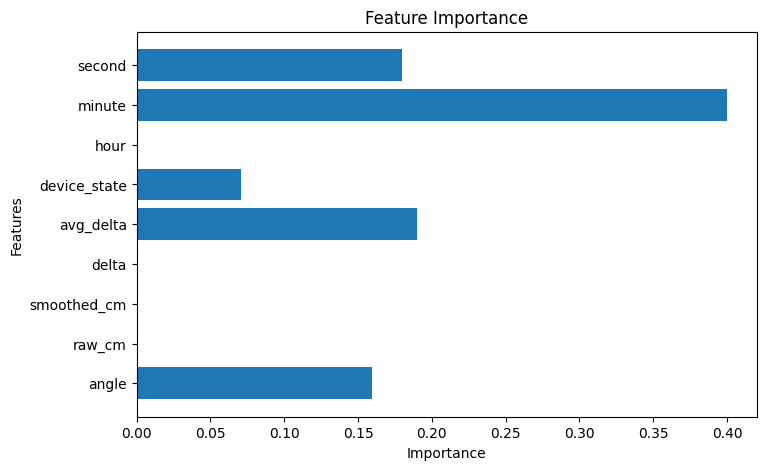

In [33]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

In [34]:
import joblib
import pandas as pd

model = joblib.load("radar_model.pkl")

sample = pd.DataFrame({
    "angle":[90],
    "raw_cm":[5.2],
    "smoothed_cm":[6.1],
    "delta":[-1.1],
    "avg_delta":[-0.5],
    "device_state":[1],
    "hour":[1],
    "minute":[34],
    "second":[10]
})

prediction = model.predict(sample)

print(prediction)

[0]


In [35]:


test_samples = pd.DataFrame([
    # Likely NO_OBJECT
    [90, 0.0, 0.0, 0.0, 0.0, 0, 1, 35, 0],

    # Object standing still
    [85, 10.2, 10.1, 0.02, 0.01, 1, 1, 35, 5],

    # Object approaching
    [88, 12.0, 10.5, -1.5, -0.8, 1, 1, 35, 10],

    # Object approaching fast
    [92, 15.0, 11.0, -2.0, -1.3, 1, 1, 35, 15],

    # Object moving away
    [95, 8.0, 9.5, 1.2, 0.8, 1, 1, 35, 20],

    # Object moving away fast
    [100, 6.0, 10.0, 2.5, 1.6, 1, 1, 35, 25],

    # Near stationary object
    [75, 7.5, 7.4, -0.05, -0.02, 1, 1, 35, 30],

    # Slight movement toward sensor
    [70, 9.0, 8.7, -0.3, -0.2, 1, 1, 35, 35],

    # Slight movement away from sensor
    [110, 8.5, 8.8, 0.3, 0.2, 1, 1, 35, 40],

    # Strong reflection at close range
    [90, 4.5, 4.7, -0.1, -0.05, 1, 1, 35, 45]
], columns=[
    "angle",
    "raw_cm",
    "smoothed_cm",
    "delta",
    "avg_delta",
    "device_state",
    "hour",
    "minute",
    "second"
])

print(test_samples)

   angle  raw_cm  smoothed_cm  delta  avg_delta  device_state  hour  minute  \
0     90     0.0          0.0   0.00       0.00             0     1      35   
1     85    10.2         10.1   0.02       0.01             1     1      35   
2     88    12.0         10.5  -1.50      -0.80             1     1      35   
3     92    15.0         11.0  -2.00      -1.30             1     1      35   
4     95     8.0          9.5   1.20       0.80             1     1      35   
5    100     6.0         10.0   2.50       1.60             1     1      35   
6     75     7.5          7.4  -0.05      -0.02             1     1      35   
7     70     9.0          8.7  -0.30      -0.20             1     1      35   
8    110     8.5          8.8   0.30       0.20             1     1      35   
9     90     4.5          4.7  -0.10      -0.05             1     1      35   

   second  
0       0  
1       5  
2      10  
3      15  
4      20  
5      25  
6      30  
7      35  
8      40  
9      45 

In [36]:


model = joblib.load("radar_model.pkl")

predictions = model.predict(test_samples)

for i, pred in enumerate(predictions):
    print(f"Sample {i+1}: {pred}")

Sample 1: 1
Sample 2: 0
Sample 3: 0
Sample 4: 0
Sample 5: 1
Sample 6: 1
Sample 7: 0
Sample 8: 0
Sample 9: 1
Sample 10: 0
